In [1]:
# Импорты
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap

# Настройка стиля графиков
plt.style.use('seaborn-v0_8')

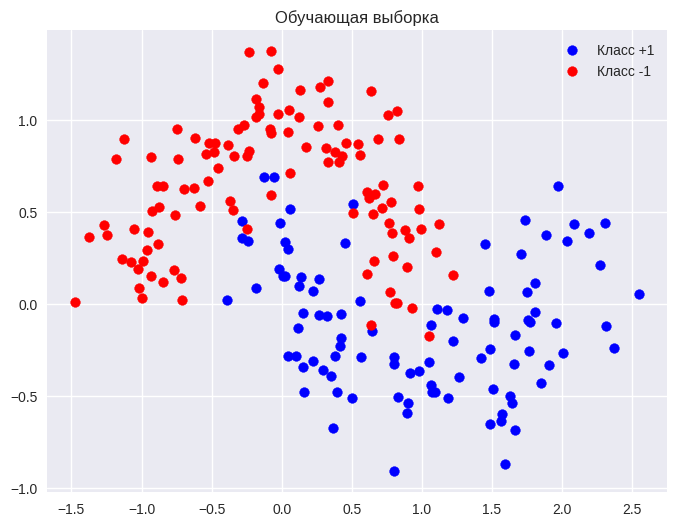

In [2]:
# Подготовка данных
# Генерируем два полумесяца (нелинейная задача)
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

# Преобразуем метки 0 в -1 для удобства метода потенциальных функций
y = np.where(y == 0, -1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Визуализация данных
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='blue', label='Класс +1')
plt.scatter(X_train[y_train == -1, 0], X_train[y_train == -1, 1], color='red', label='Класс -1')
plt.title("Обучающая выборка")
plt.legend()
plt.show()

In [3]:
class ParzenWindowClassifier:
    def __init__(self, h=0.5, kernel='gaussian'):
        self.h = h
        self.kernel_type = kernel
        self.X_train = None
        self.y_train = None
        self.classes = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        self.classes = np.unique(y)

    def _gaussian_kernel(self, distance):
        return (1 / (np.sqrt(2 * np.pi))) * np.exp(-0.5 * (distance ** 2))

    def predict_proba(self, X):
        # Вычисляем плотности для каждого класса
        probs = np.zeros((X.shape[0], len(self.classes)))

        for idx, cls in enumerate(self.classes):
            X_cls = self.X_train[self.y_train == cls]

            # Для каждой точки из X считаем сумму ядер от точек обучающей выборки
            for i, x_query in enumerate(X):
                # Евклидово расстояние
                dists = np.linalg.norm(X_cls - x_query, axis=1)
                # Применяем ядро с шириной h
                kernel_vals = self._gaussian_kernel(dists / self.h)
                # Суммируем вклады (без нормировки на N*h, так как сравниваем классы между собой)
                probs[i, idx] = np.sum(kernel_vals)

        return probs

    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes[np.argmax(probs, axis=1)]

# Вспомогательная функция для отрисовки границ
def plot_decision_boundary(clf, X, y, title=""):
    h = .05  # шаг сетки
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', edgecolors='k', label='+1')
    plt.scatter(X[y == -1, 0], X[y == -1, 1], c='red', edgecolors='k', label='-1')
    plt.title(title)
    plt.show()

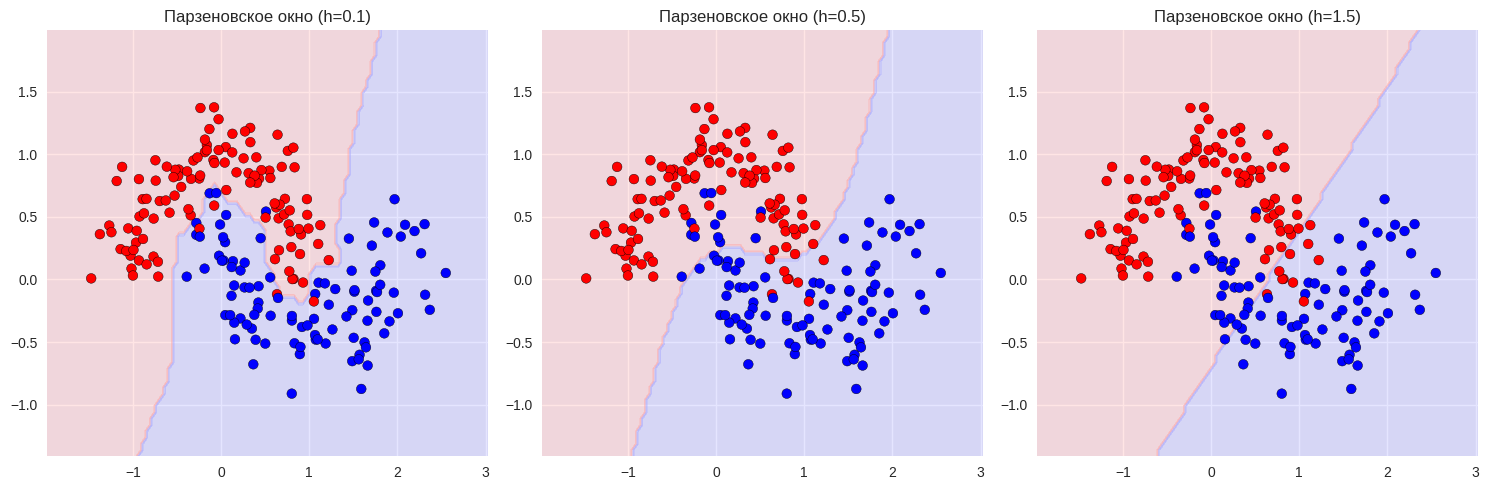

In [11]:
# Тестирование Парзеновского окна с разной шириной h
h_values = [0.1, 0.5, 1.5]

plt.figure(figsize=(15, 5))

for i, h in enumerate(h_values):
    clf = ParzenWindowClassifier(h=h)
    clf.fit(X_train, y_train)

    plt.subplot(1, 3, i+1)

    # Копируем логику plot_decision_boundary сюда для subplots
    xx_min, xx_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    yy_min, yy_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(xx_min, xx_max, 0.05),
                         np.arange(yy_min, yy_max, 0.05))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=ListedColormap(['#FF0000', '#0000FF']), edgecolors='k')
    plt.title(f'Парзеновское окно (h={h})')

plt.tight_layout()
plt.show()

In [6]:
class PotentialFunctionClassifier:
    def __init__(self, h=1.0, epochs=10):
        self.h = h
        self.epochs = epochs
        # Храним точки, в которых был добавлен потенциал, и их веса
        self.support_vectors_ = []
        self.charges_ = []

    def _kernel(self, u):
        # Гауссово ядро
        return np.exp(-1 * (u ** 2))

    def fit(self, X, y):
        n_samples = X.shape[0]
        self.support_vectors_ = []
        self.charges_ = []

        # Итеративное обучение
        for epoch in range(self.epochs):
            errors = 0
            for i in range(n_samples):
                x_curr = X[i]
                y_true = y[i]

                # Текущее предсказание на основе накопленных потенциалов
                decision_val = self._decision_function_single(x_curr)
                y_pred = 1 if decision_val > 0 else -1

                # Если ошиблись, добавляем потенциал
                if y_pred != y_true:
                    self.support_vectors_.append(x_curr)
                    self.charges_.append(y_true) # Добавляем заряд знака класса
                    errors += 1

            # Если ошибок нет, выходим раньше
            if errors == 0:
                print(f"Сходимость достигнута на эпохе {epoch}")
                break

    def _decision_function_single(self, x):
        if not self.support_vectors_:
            return 0

        # Считаем сумму потенциалов от всех "опорных" точек
        support_vectors = np.array(self.support_vectors_)
        charges = np.array(self.charges_)

        dists = np.linalg.norm(support_vectors - x, axis=1)
        # K(r) = exp(-(r/h)^2)
        kernels = self._kernel(dists / self.h)
        return np.sum(charges * kernels)

    def predict(self, X):
        preds = []
        for x in X:
            val = self._decision_function_single(x)
            preds.append(1 if val > 0 else -1)
        return np.array(preds)

Количество накопленных потенциалов (корректировок): 431


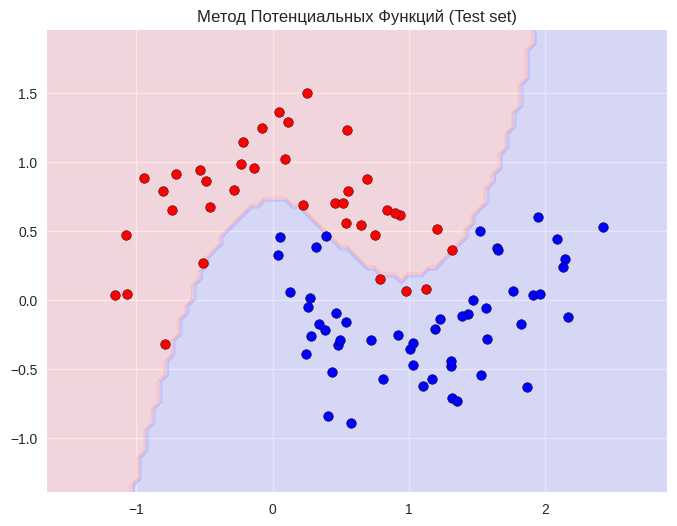

In [10]:
pot_clf = PotentialFunctionClassifier(h=1.5, epochs=20)
pot_clf.fit(X_train, y_train)

print(f"Количество накопленных потенциалов (корректировок): {len(pot_clf.charges_)}")

# Визуализация
plt.figure(figsize=(8, 6))
plot_decision_boundary(pot_clf, X_test, y_test, title="Метод Потенциальных Функций (Test set)")

# Лабораторная работа

Применить метод Парзеновского окна и метод Потенциальных функций для решения задачи медицинской диагностики (Диагностика рака груди), подобрать оптимальные гиперпараметры и визуализировать границы принятия решений (Границы отрисовывать для двух самых значимых признаков).

Датасет: sklearn.datasets.load_breast_cancer.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap

# Настройки графиков
plt.style.use('seaborn-v0_8')

In [ ]:
# Загрузка данных
data = load_breast_cancer()
X_raw, y_raw = data.data, data.target

In [ ]:
# Предобработка
# Метрические методы критичны к масштабу, поэтому StandardScaling обязателен
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

In [ ]:
# Понижение размерности до 2D для визуализации
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Доля объясненной дисперсии 2 компонентами: {np.sum(pca.explained_variance_ratio_):.2f}")

In [ ]:
# Разделение на train/test
# Stratify сохраняет баланс классов
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_raw, test_size=0.3, random_state=42, stratify=y_raw
)

In [ ]:
# Визуализация датасета в 2D
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolor='k', alpha=0.7)
plt.legend(handles=scatter.legend_elements()[0], labels=['Malignant (0)', 'Benign (1)'])
plt.title("Breast Cancer Dataset (PCA projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()